# Task 3 — Data Visualization & Interactive Dashboard

## UCI Online Retail II Dataset

**Internship:** CODSOFT Data Analytics Internship  
**Tools:** Python, Pandas, Matplotlib, Seaborn, Power BI

### Objective
- Create meaningful visualizations from the cleaned dataset
- Identify trends and patterns through charts
- Analyze sales, products, countries, and transactions
- Present business insights visually
- Build an interactive dashboard using Power BI

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = r"C:\Users\ITGADGET\Desktop\CODSOFT_DATA_ANALYTICS\Task 1\Data\cleaned_online_retail.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1050081, 8)


In [4]:
print("First 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data types:
Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object


In [5]:
df["TotalAmount"] = df["Quantity"] * df["Price"]

print("TotalAmount column created successfully!")
display(df[["Quantity", "Price", "TotalAmount"]].head())

TotalAmount column created successfully!


,Quantity,Price,TotalAmount
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [6]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("InvoiceDate converted successfully!")
print(df["InvoiceDate"].dtype)

InvoiceDate converted successfully!
datetime64[us]


In [7]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month

print("Year and Month columns created successfully!")
display(df[["InvoiceDate", "Year", "Month"]].head())

Year and Month columns created successfully!


,InvoiceDate,Year,Month
0,2009-12-01 07:45:00,2009,12
1,2009-12-01 07:45:00,2009,12
2,2009-12-01 07:45:00,2009,12
3,2009-12-01 07:45:00,2009,12
4,2009-12-01 07:45:00,2009,12


In [8]:
monthly_sales = (
    df.groupby(["Year", "Month"])["TotalAmount"]
    .sum()
)

print("Monthly sales calculated successfully!")
display(monthly_sales)

Monthly sales calculated successfully!


Year  Month
2009  12        796648.500
2010  1         622479.502
      2         531265.366
      3         763247.241
      4         641521.052
      5         613270.720
      6         677073.870
      7         617365.480
      8         654774.390
      9         851105.961
      10       1080611.480
      11       1416697.202
      12       1122990.430
2011  1         558448.560
      2         497026.410
      3         682013.980
      4         492367.841
      5         722094.100
      6         689977.230
      7         680156.991
      8         692448.520
      9        1017596.682
      10       1069368.230
      11       1456145.800
      12        432719.060
Name: TotalAmount, dtype: float64

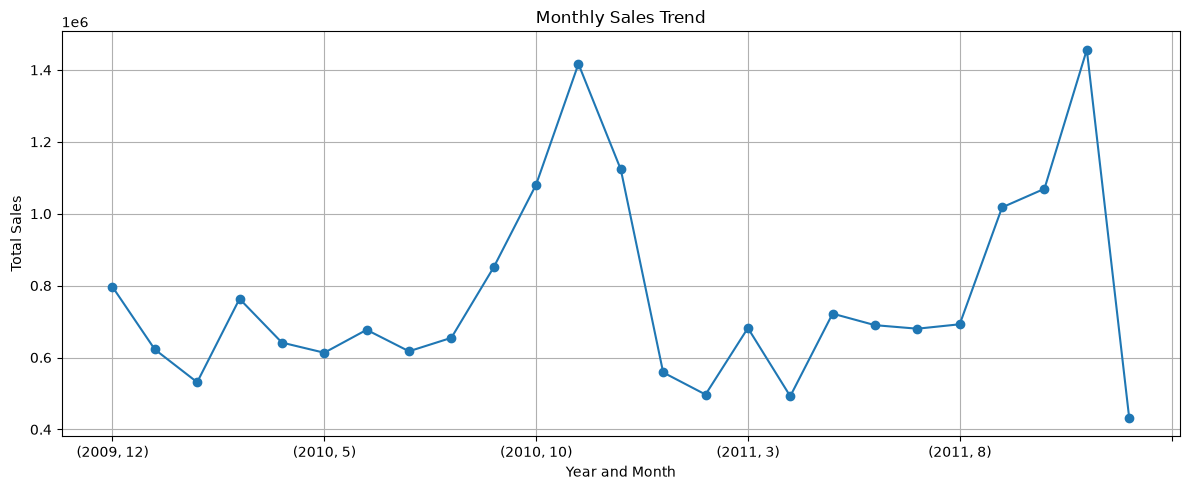

In [9]:
monthly_sales.plot(
    kind="line",
    figsize=(12, 5),
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Year and Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
top_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


print("Top 10 products by quantity sold:")
display(top_products)

Top 10 products by quantity sold:


Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     108305
WHITE HANGING HEART T-LIGHT HOLDER     92930
ASSORTED COLOUR BIRD ORNAMENT          81087
JUMBO BAG RED RETROSPOT                77928
BROCADE RING PURSE                     70664
PACK OF 60 PINK PAISLEY CAKE CASES     56406
60 TEATIME FAIRY CAKE CASES            54187
SMALL POPCORN HOLDER                   49590
PACK OF 72 RETROSPOT CAKE CASES        49283
PACK OF 72 RETRO SPOT CAKE CASES       46079
Name: Quantity, dtype: int64

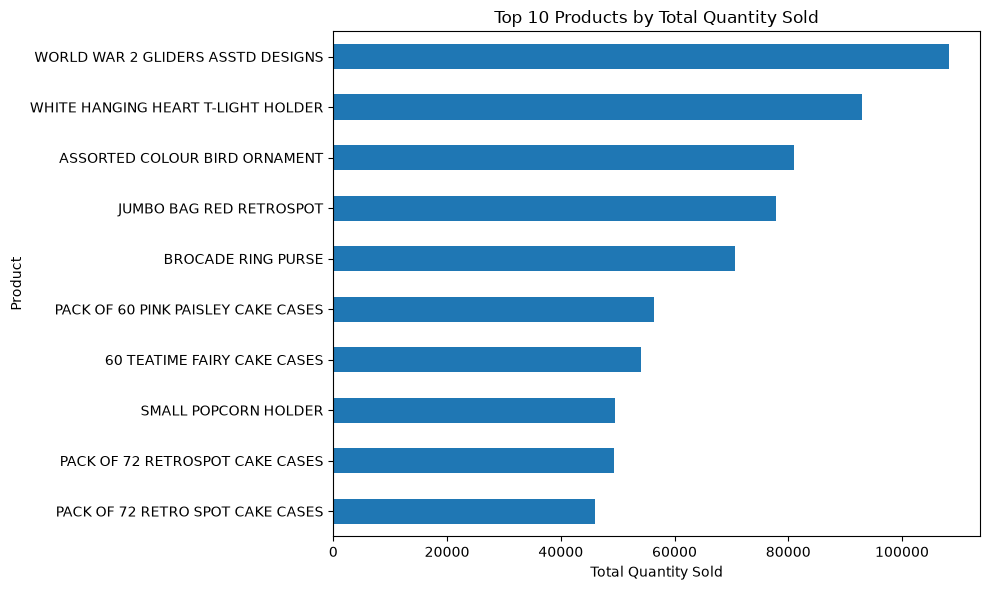

In [11]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Total Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


In [12]:
country_sales = (
    df.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Countries by Total Sales:")
display(country_sales)

Top 10 Countries by Total Sales:


Country
United Kingdom    1.647644e+07
EIRE              6.152291e+05
Netherlands       5.485233e+05
Germany           4.174299e+05
France            3.279967e+05
Australia         1.670616e+05
Switzerland       9.970646e+04
Spain             9.180816e+04
Sweden            8.777552e+04
Denmark           6.574109e+04
Name: TotalAmount, dtype: float64

In [13]:
country_sales = (
    df.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Countries by Total Sales:")
display(country_sales)

Top 10 Countries by Total Sales:


Country
United Kingdom    1.647644e+07
EIRE              6.152291e+05
Netherlands       5.485233e+05
Germany           4.174299e+05
France            3.279967e+05
Australia         1.670616e+05
Switzerland       9.970646e+04
Spain             9.180816e+04
Sweden            8.777552e+04
Denmark           6.574109e+04
Name: TotalAmount, dtype: float64

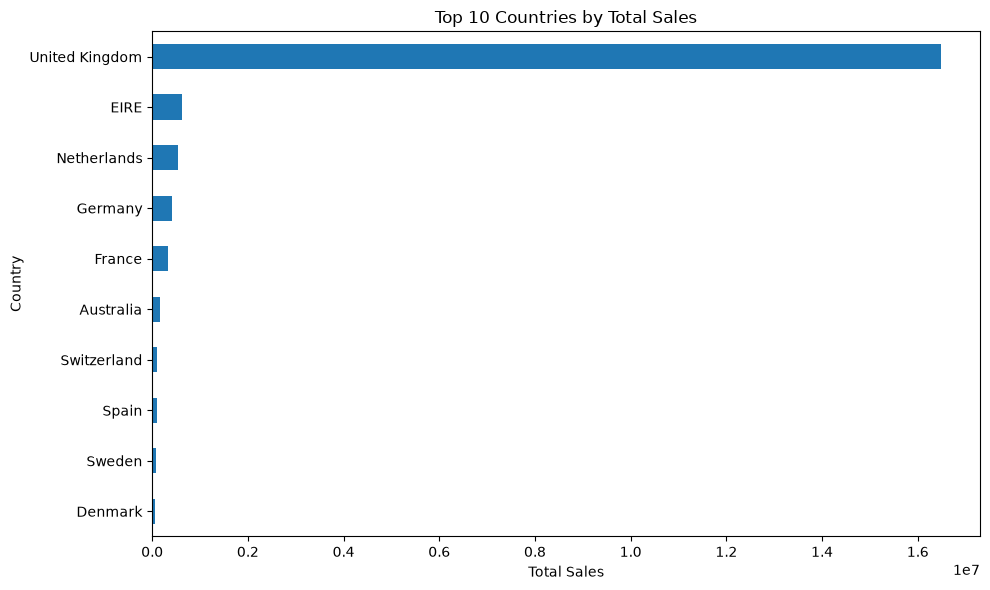

In [14]:
plt.figure(figsize=(10, 6))

country_sales.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

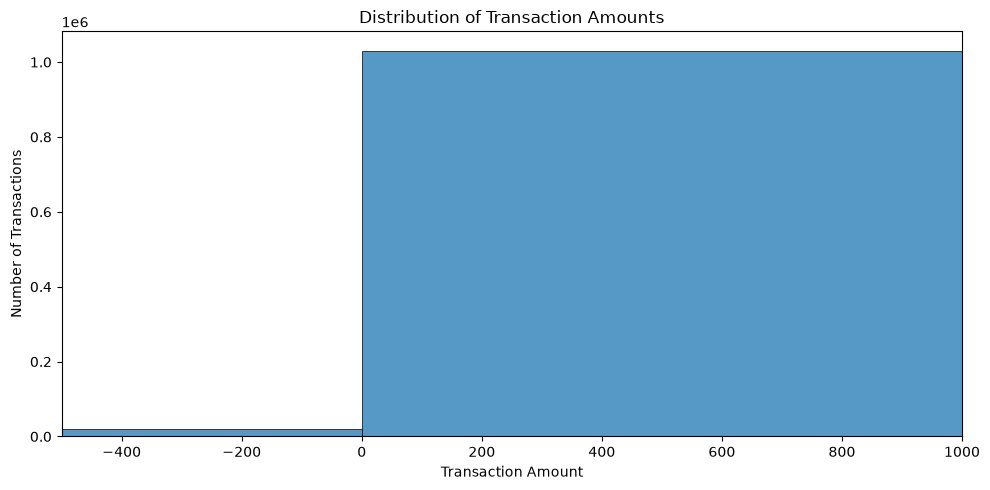

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["TotalAmount"],
    bins=100
)

plt.xlim(-500, 1000)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

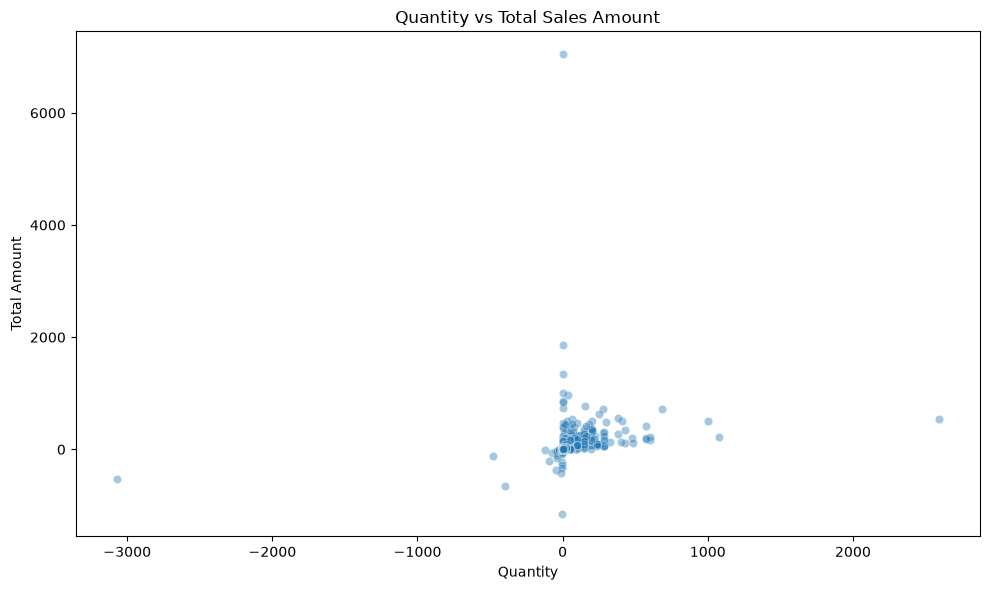

In [16]:
sample_df = df.sample(10000, random_state=42)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="Quantity",
    y="TotalAmount",
    alpha=0.4
)

plt.title("Quantity vs Total Sales Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.tight_layout()
plt.show()

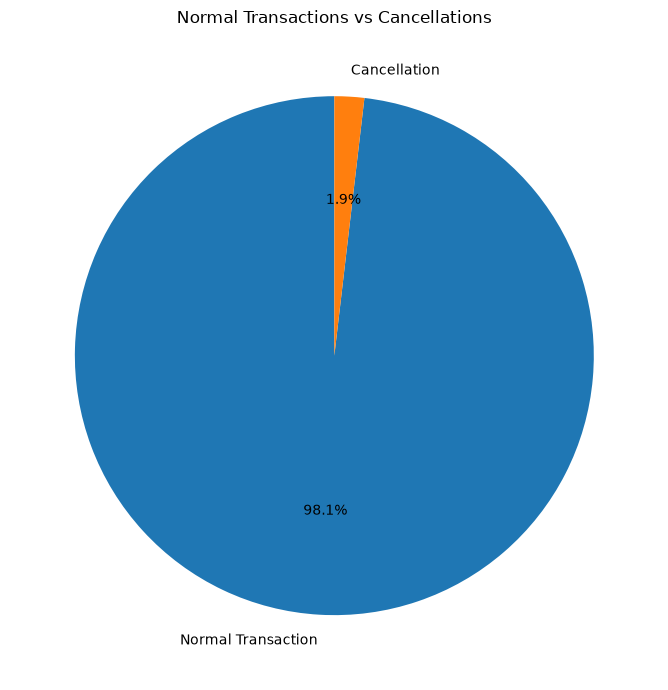

In [17]:
transaction_counts = df["Invoice"].astype(str).str.startswith("C").map({
    True: "Cancellation",
    False: "Normal Transaction"
}).value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    transaction_counts,
    labels=transaction_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Normal Transactions vs Cancellations")
plt.tight_layout()
plt.show()

## Key Visualization Insights

- Monthly sales show noticeable variation across the observed period, with stronger sales activity during some months.
- The United Kingdom contributes the largest share of sales among the countries in the dataset.
- A small group of products accounts for a large quantity of total units sold.
- The transaction distribution is concentrated around smaller transaction amounts, while extreme values create a long tail.
- The scatter plot shows a positive relationship between quantity and total transaction amount.
- Cancellation transactions represent a smaller proportion compared with normal transactions.
- The visualizations help identify important sales trends, product patterns, country-level performance, and unusual transaction behavior.